## Run_15: standardizzazione dati, cross validation e allineamento finestre 

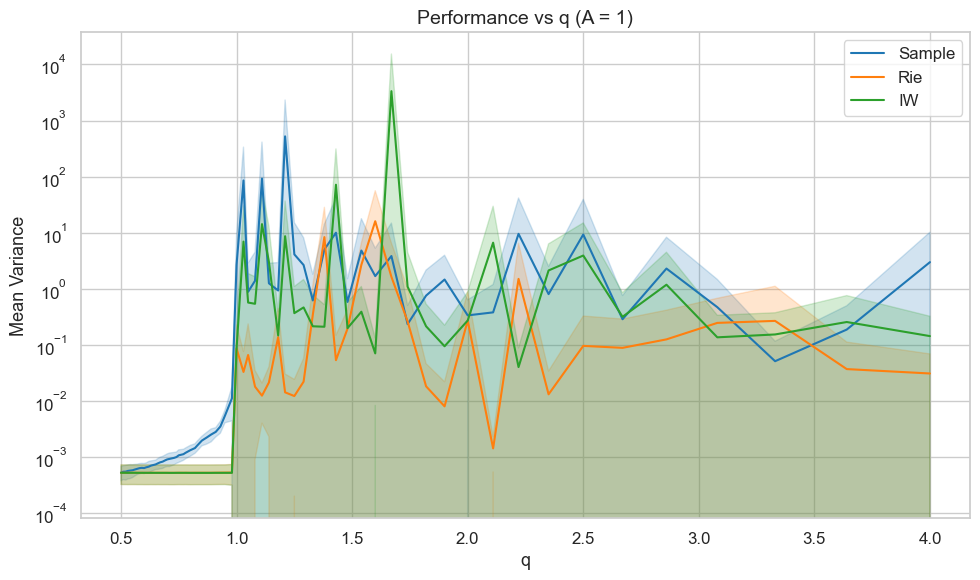

Grafico salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15/performance_vs_Q_A_1.pdf


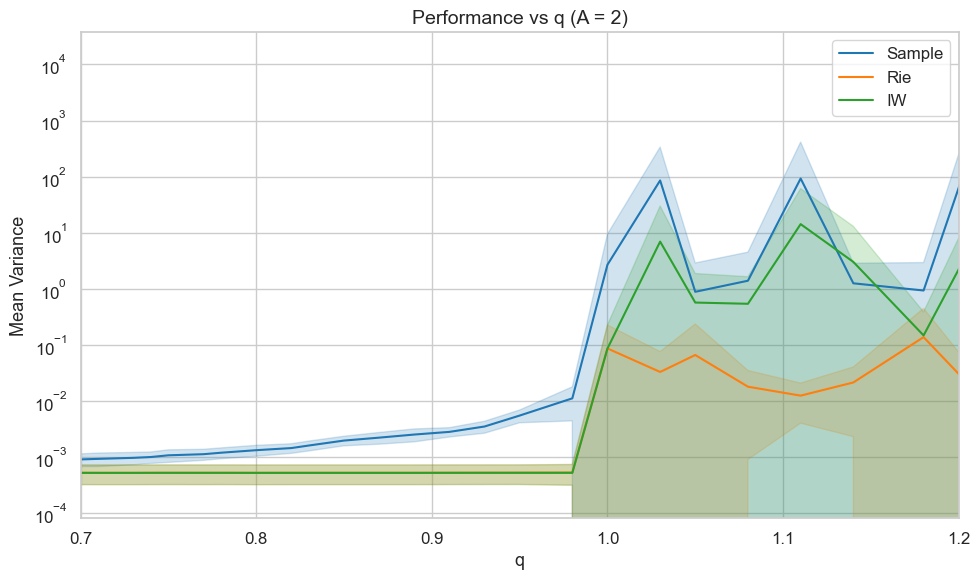

Grafico salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15/performance_vs_Q_A_2.pdf


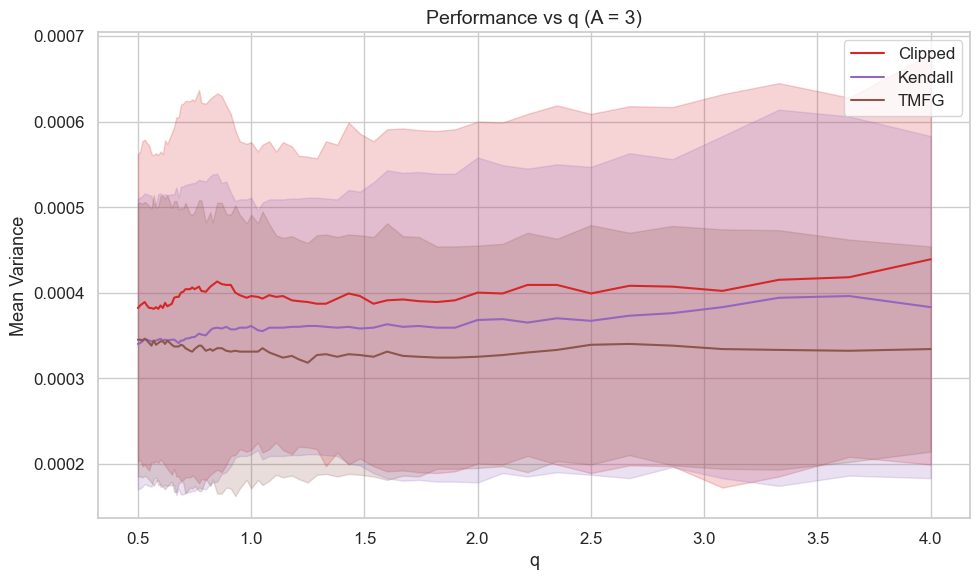

Grafico salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15/performance_vs_Q_A_3.pdf


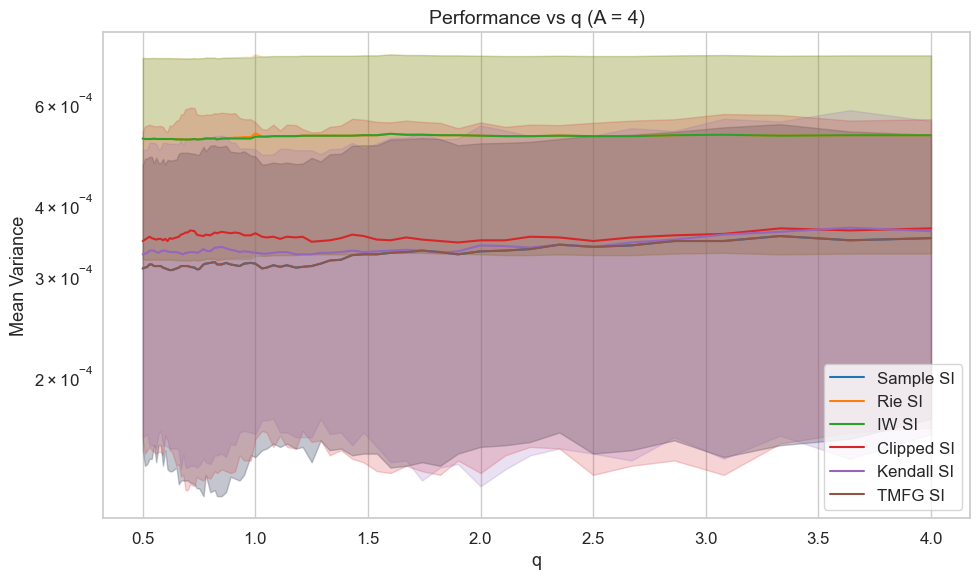

Grafico salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15/performance_vs_Q_A_4.pdf


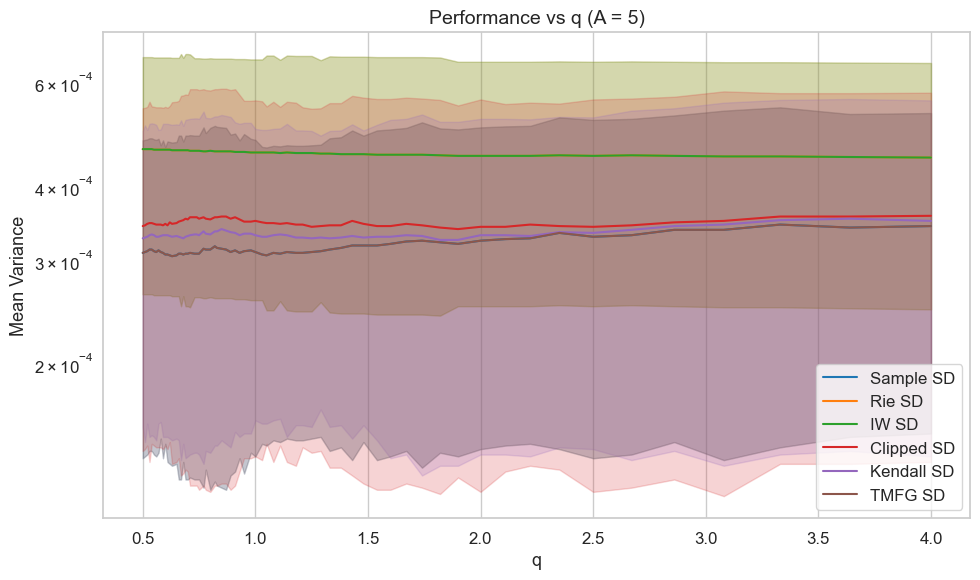

Grafico salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15/performance_vs_Q_A_5.pdf


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_performance_vs_Q(input_dir):
    sns.set(style="whitegrid", font_scale=1.1)
    result_file = os.path.join(input_dir, "risultati_finali.txt")

    if not os.path.exists(result_file):
        print(f"File non trovato: {result_file}")
        sys.exit(1)

    df = pd.read_csv(result_file)

    # Conversioni sicure
    df["mean"] = pd.to_numeric(df["mean"], errors='coerce')
    df["variance"] = pd.to_numeric(df["variance"], errors='coerce')
    df["Q"] = pd.to_numeric(df["Q"], errors='coerce')
    df["std"] = df["variance"]

    # Tutti i metodi da includere
    method_groups = {
        1: ["Sample_", "Rie____", "IW_____"],
        2: ["Sample_", "Rie____", "IW_____"],
        3: ["Clipped", "Kendall", "TMFG___"],
        4: ["Sample__SI", "Rie_____SI", "IW______SI", "Clipped_SI", "Kendall_SI", "TMFG____SI"],
        5: ["Sample__SD", "Rie_____SD", "IW______SD", "Clipped_SD", "Kendall_SD", "TMFG____SD"]
    }

    methods = ['Sample_', 'Rie____', 'IW_____', 'Clipped', 'Kendall', 'TMFG___']
    selected_methods = ["TMFG", "Kendall", "Clipped"]

     # === 3. Palette coerente per nomi base ===
    base_methods = ['Sample', 'Rie', 'IW', 'Clipped', 'Kendall', 'TMFG']
    palette = sns.color_palette("tab10", n_colors=len(base_methods))
    base_color_map = {base: palette[i] for i, base in enumerate(base_methods)}

    # Funzione di mappatura base -> colore anche per i metodi shrinkati
    def extract_base_name(method):
        if "SI" in method:
            method = method.replace("__SI", "").replace("_SI", "")
        elif "SD" in method:
            method = method.replace("__SD", "").replace("_SD", "")
        return method.replace("_", "").replace("___", "").replace("__", "").replace("_____", "").replace("______", "").replace("_______", "")

    # Costruzione della color map completa
    all_methods = sorted(set(m for group in method_groups.values() for m in group))
    color_map = {}
    for method in all_methods:
        base_name = extract_base_name(method)
        # Trova il primo base method che è substring di base_name
        matched_base = next((b for b in base_methods if b.lower() in base_name.lower()), None)
        if matched_base:
            color_map[method] = base_color_map[matched_base]
        else:
            color_map[method] = "black"  # fallback
    for A in range(1, 6):
        plt.figure(figsize=(10, 6))
        methods = method_groups[A]

        for method in methods:
            df_method = df[df["method"] == method].sort_values("Q")
            if df_method.empty:
                continue

            Q = df_method["Q"].values
            mean = df_method["mean"].values
            std = df_method["std"].values

            label_clean = method.replace("_", "").replace("SI", " SI").replace("SD", " SD")
            plt.plot(Q, mean, label=label_clean, color=color_map[method])
            plt.fill_between(Q, mean - std, mean + std, alpha=0.2, color=color_map[method])

        if A in [1, 2, 4, 5]:
            plt.yscale("log")
        if A == 2:
            plt.xlim(0.7, 1.2)

        plt.xlabel("q", fontsize=13)
        plt.ylabel("Mean Variance", fontsize=13)
        plt.title(f"Performance vs q (A = {A})", fontsize=14)
        plt.legend()
        plt.tight_layout()

        plt.show()

        output_path = os.path.join(input_dir, f"performance_vs_Q_A_{A}.pdf")
        plt.savefig(output_path)
        print(f"Grafico salvato in: {output_path}")
        plt.close()

if __name__ == "__main__":
   
    input_directory = "/Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15"
    plot_performance_vs_Q(input_directory)

Grafico combinato salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15/performance_vs_Q_A2_A3.pdf


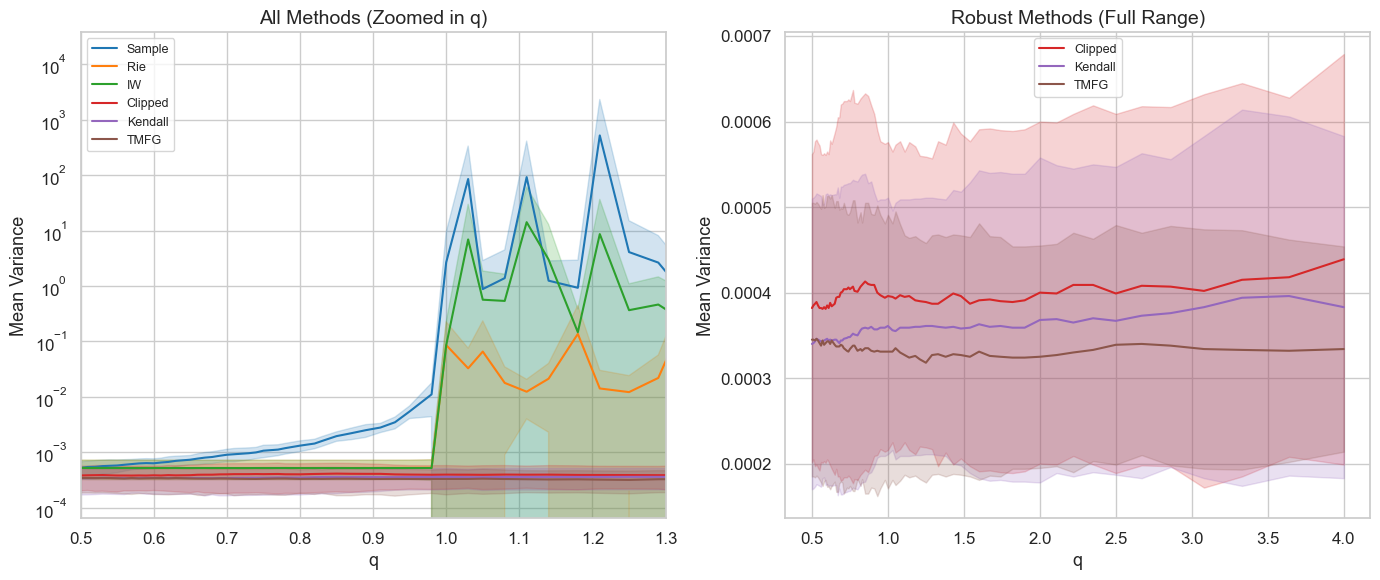

Grafico combinato salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15/performance_vs_Q_A4_A5.pdf


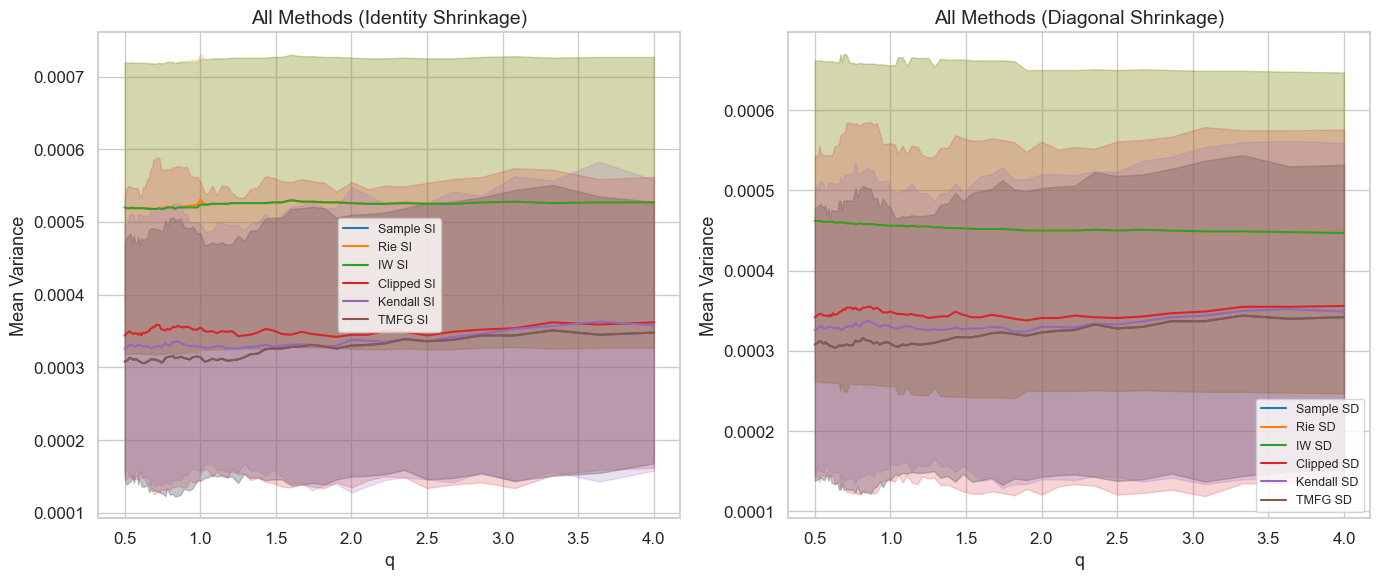

In [16]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_performance_vs_Q(input_dir, coppie_plot=[2,3], titoli_plot=None):
    sns.set(style="whitegrid", font_scale=1.1)
    result_file = os.path.join(input_dir, "risultati_finali.txt")

    if not os.path.exists(result_file):
        print(f"File non trovato: {result_file}")
        sys.exit(1)

    df = pd.read_csv(result_file)

    df["mean"] = pd.to_numeric(df["mean"], errors='coerce')
    df["variance"] = pd.to_numeric(df["variance"], errors='coerce')
    df["Q"] = pd.to_numeric(df["Q"], errors='coerce')
    df["std"] = df["variance"]

    method_groups = {
        1: ["Sample_", "Rie____", "IW_____"],
        2: ["Sample_", "Rie____", "IW_____", "Clipped", "Kendall", "TMFG___"],
        3: ["Clipped", "Kendall", "TMFG___"],
        4: ["Sample__SI", "Rie_____SI", "IW______SI", "Clipped_SI", "Kendall_SI", "TMFG____SI"],
        5: ["Sample__SD", "Rie_____SD", "IW______SD", "Clipped_SD", "Kendall_SD", "TMFG____SD"]
    }

    base_methods = ['Sample', 'Rie', 'IW', 'Clipped', 'Kendall', 'TMFG']
    palette = sns.color_palette("tab10", n_colors=len(base_methods))
    base_color_map = {base: palette[i] for i, base in enumerate(base_methods)}

    def extract_base_name(method):
        if "SI" in method:
            method = method.replace("__SI", "").replace("_SI", "")
        elif "SD" in method:
            method = method.replace("__SD", "").replace("_SD", "")
        return method.replace("_", "").replace("___", "").replace("__", "").replace("_____", "").replace("______", "").replace("_______", "")

    all_methods = sorted(set(m for group in method_groups.values() for m in group))
    color_map = {}
    for method in all_methods:
        base_name = extract_base_name(method)
        matched_base = next((b for b in base_methods if b.lower() in base_name.lower()), None)
        color_map[method] = base_color_map.get(matched_base, "black")

    # Default titoli se non forniti
    if titoli_plot is None:
        titoli_plot = {
            2: "Plot A = 2: Shrinkage Methods",
            3: "Plot A = 3: Filtering Methods"
        }

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    for idx, A in enumerate([coppie_plot[0], coppie_plot[1]]):
        ax = axs[idx]
        methods = method_groups[A]

        for method in methods:
            df_method = df[df["method"] == method].sort_values("Q")
            if df_method.empty:
                continue

            Q = df_method["Q"].values
            mean = df_method["mean"].values
            std = df_method["std"].values

            label_clean = method.replace("_", "").replace("SI", " SI").replace("SD", " SD")
            ax.plot(Q, mean, label=label_clean, color=color_map[method])
            ax.fill_between(Q, mean - std, mean + std, alpha=0.2, color=color_map[method])

        if A == 2:
            ax.set_xlim(0.5, 1.3)
            ax.set_yscale("log")

        ax.set_xlabel("q", fontsize=13)
        ax.set_ylabel("Mean Variance", fontsize=13)
        ax.set_title(titoli_plot.get(A, f"Performance vs q (A = {A})"), fontsize=14)
        ax.legend(fontsize=9)

    plt.tight_layout()
    output_path = os.path.join(input_dir, f"performance_vs_Q_A{coppie_plot[0]}_A{coppie_plot[1]}.pdf")
    plt.savefig(output_path)
    print(f"Grafico combinato salvato in: {output_path}")
    plt.show()

if __name__ == "__main__":
    input_directory = "/Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_15"
    plot_performance_vs_Q(
        input_directory,
        coppie_plot=[2, 3],
        titoli_plot={
            2: "All Methods (Zoomed in q)",
            3: "Robust Methods (Full Range)"
        }
    )

    plot_performance_vs_Q(
        input_directory,
        coppie_plot=[4, 5],
        titoli_plot={
            4: "All Methods (Identity Shrinkage)",
            5: "All Methods (Diagonal Shrinkage)"
        }
    )

## Run_16: cross validation e allineamento finestre 

Grafico combinato salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_16/performance_vs_Q_A2_A3.pdf


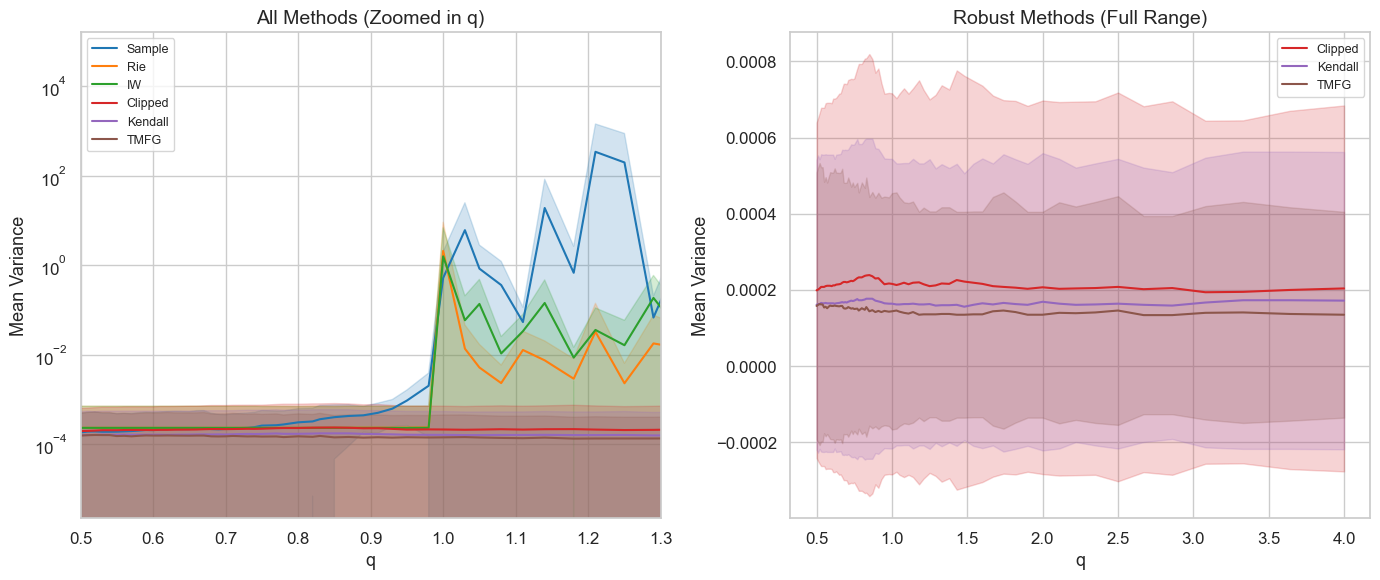

Grafico combinato salvato in: /Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_16/performance_vs_Q_A4_A5.pdf


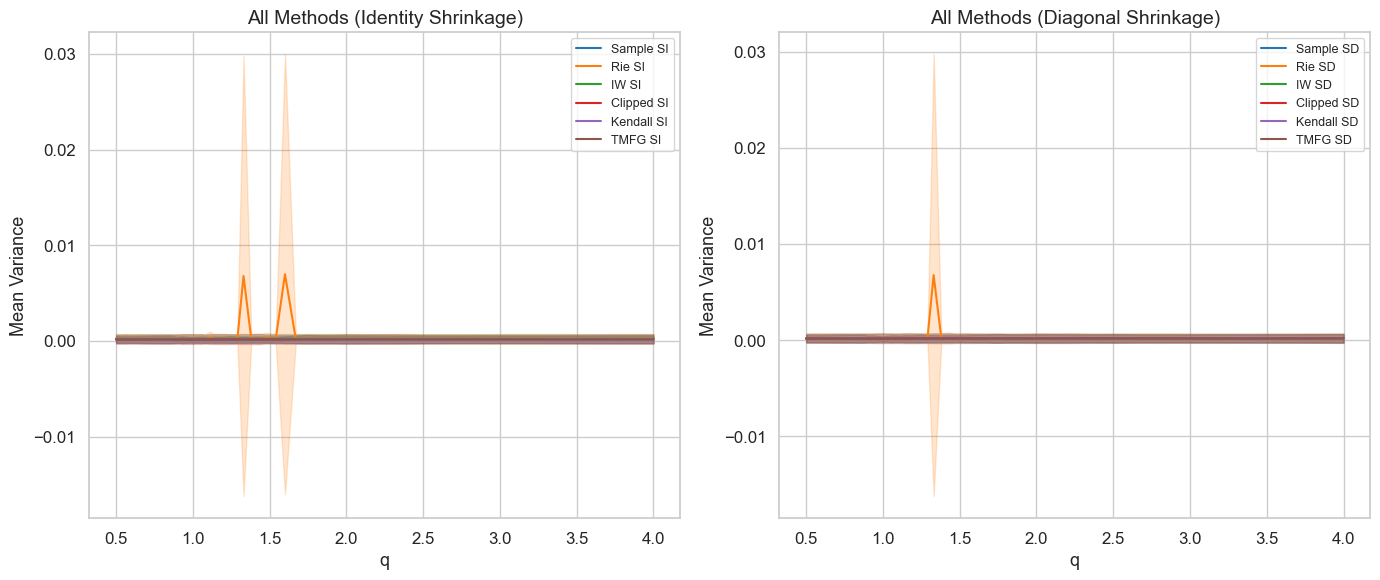

In [17]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_performance_vs_Q(input_dir, coppie_plot=[2,3], titoli_plot=None):
    sns.set(style="whitegrid", font_scale=1.1)
    result_file = os.path.join(input_dir, "risultati_finali.txt")

    if not os.path.exists(result_file):
        print(f"File non trovato: {result_file}")
        sys.exit(1)

    df = pd.read_csv(result_file)

    df["mean"] = pd.to_numeric(df["mean"], errors='coerce')
    df["variance"] = pd.to_numeric(df["variance"], errors='coerce')
    df["Q"] = pd.to_numeric(df["Q"], errors='coerce')
    df["std"] = df["variance"]

    method_groups = {
        1: ["Sample_", "Rie____", "IW_____"],
        2: ["Sample_", "Rie____", "IW_____", "Clipped", "Kendall", "TMFG___"],
        3: ["Clipped", "Kendall", "TMFG___"],
        4: ["Sample__SI", "Rie_____SI", "IW______SI", "Clipped_SI", "Kendall_SI", "TMFG____SI"],
        5: ["Sample__SD", "Rie_____SD", "IW______SD", "Clipped_SD", "Kendall_SD", "TMFG____SD"]
    }

    base_methods = ['Sample', 'Rie', 'IW', 'Clipped', 'Kendall', 'TMFG']
    palette = sns.color_palette("tab10", n_colors=len(base_methods))
    base_color_map = {base: palette[i] for i, base in enumerate(base_methods)}

    def extract_base_name(method):
        if "SI" in method:
            method = method.replace("__SI", "").replace("_SI", "")
        elif "SD" in method:
            method = method.replace("__SD", "").replace("_SD", "")
        return method.replace("_", "").replace("___", "").replace("__", "").replace("_____", "").replace("______", "").replace("_______", "")

    all_methods = sorted(set(m for group in method_groups.values() for m in group))
    color_map = {}
    for method in all_methods:
        base_name = extract_base_name(method)
        matched_base = next((b for b in base_methods if b.lower() in base_name.lower()), None)
        color_map[method] = base_color_map.get(matched_base, "black")

    # Default titoli se non forniti
    if titoli_plot is None:
        titoli_plot = {
            2: "Plot A = 2: Shrinkage Methods",
            3: "Plot A = 3: Filtering Methods"
        }

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

    for idx, A in enumerate([coppie_plot[0], coppie_plot[1]]):
        ax = axs[idx]
        methods = method_groups[A]

        for method in methods:
            df_method = df[df["method"] == method].sort_values("Q")
            if df_method.empty:
                continue

            Q = df_method["Q"].values
            mean = df_method["mean"].values
            std = df_method["std"].values

            label_clean = method.replace("_", "").replace("SI", " SI").replace("SD", " SD")
            ax.plot(Q, mean, label=label_clean, color=color_map[method])
            ax.fill_between(Q, mean - std, mean + std, alpha=0.2, color=color_map[method])

        if A == 2:
            ax.set_xlim(0.5, 1.3)
            ax.set_yscale("log")

        ax.set_xlabel("q", fontsize=13)
        ax.set_ylabel("Mean Variance", fontsize=13)
        ax.set_title(titoli_plot.get(A, f"Performance vs q (A = {A})"), fontsize=14)
        ax.legend(fontsize=9)

    plt.tight_layout()
    output_path = os.path.join(input_dir, f"performance_vs_Q_A{coppie_plot[0]}_A{coppie_plot[1]}.pdf")
    plt.savefig(output_path)
    print(f"Grafico combinato salvato in: {output_path}")
    plt.show()

if __name__ == "__main__":
    input_directory = "/Users/alessandromazzeo/Desktop/UCL/BackUp_Risultati/Run_16"
    plot_performance_vs_Q(
        input_directory,
        coppie_plot=[2, 3],
        titoli_plot={
            2: "All Methods (Zoomed in q)",
            3: "Robust Methods (Full Range)"
        }
    )

    plot_performance_vs_Q(
        input_directory,
        coppie_plot=[4, 5],
        titoli_plot={
            4: "All Methods (Identity Shrinkage)",
            5: "All Methods (Diagonal Shrinkage)"
        }
    )